In [70]:
from datasets import load_dataset
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

In [71]:
MODEL = "Qwen/Qwen3-8B"
TOKENIZER = AutoTokenizer.from_pretrained (MODEL)

In [17]:
dataset = load_dataset ("parquet", data_files = r"C:\Users\Admin\Desktop\MAIA\SLD\Datasets\DatasetTokenizado.parquet", split = "train")

display (dataset.features)
display (dataset[0])
print (dataset)

Generating train split: 774447 examples [00:09, 78016.51 examples/s] 


{'input_ids': List(Value('int32')), 'attention_mask': List(Value('int8'))}

{'input_ids': [151644,
  872,
  198,
  1912,
  1709,
  21791,
  297,
  2543,
  963,
  10681,
  815,
  1036,
  32,
  8376,
  64,
  29134,
  7806,
  469,
  57608,
  264,
  1197,
  9696,
  854,
  2053,
  1617,
  264,
  19408,
  291,
  10782,
  5411,
  2635,
  768,
  1137,
  64,
  30,
  151645,
  198,
  151644,
  77091,
  198,
  151667,
  271,
  151668,
  271,
  42990,
  2543,
  963,
  10681,
  815,
  7756,
  64,
  264,
  139669,
  2994,
  12139,
  86585,
  384,
  653,
  68279,
  15027,
  91724,
  83,
  23137,
  17141,
  1351,
  33465,
  47271,
  9823,
  2782,
  13,
  83767,
  485,
  1709,
  438,
  45962,
  70502,
  309,
  264,
  4536,
  71,
  685,
  409,
  57608,
  438,
  1367,
  265,
  10938,
  384,
  949,
  84110,
  2643,
  41398,
  36152,
  13,
  19801,
  79594,
  11,
  4443,
  1947,
  288,
  3413,
  70502,
  30741,
  348,
  1659,
  2643,
  41398,
  61862,
  264,
  140031,
  1709,
  1443,
  2758,
  645,
  297,
  20009,
  54639,
  384,
  1197,
  9696,
  297,
  14116,
  2994,
  19345,
  

Dataset({
    features: ['input_ids', 'attention_mask'],
    num_rows: 774447
})


In [25]:
TOKENS = []

for x in dataset["input_ids"]:

    TOKENS.append (len (x)) # len é fulcral para ter o NÚMERO DE TOKENS


In [50]:
#print (f"Tokens Processados no Treino: {np.sum (TOKENS)} tokens") # 619947163
#print (len(TOKENS)) # 774447
"""
Aqui pode parecer estranho não ser igual ao que o Config mostra mas é preciso não esquecer que este valor corresponde à Tokenização COM Chat Template.
Este valor é importante porque este é o número de Tokens que vão ser processados no TREINO.

len (TOKENS) é excelente para mostrar que todos os exemplos estão tokenizados.
"""
################################################################################

MIN = min(TOKENS)
print (f"MINIMUN: {MIN} tokens")

MAX = max(TOKENS)
print (f"MAX: {MAX} tokens")

MÉDIA = np.mean (TOKENS)
print (f"Média: {MÉDIA:.0f} tokens")

P50 = np.percentile (TOKENS, 50)
print (f"Mediana: {P50:.0f} tokens")

P75 = np.percentile (TOKENS, 75)
print (f"P75: {P75:.0f} tokens")

P90 = np.percentile (TOKENS, 90)
print (f"P90: {P90:.0f} tokens")

P95 = np.percentile (TOKENS, 95)
print (f"P95: {P95:.0f} tokens")

P99 = np.percentile (TOKENS, 99)
print (f"P99: {P99:.0f} tokens")

MINIMUN: 26 tokens
MAX: 5128 tokens
Média: 801 tokens
Mediana: 727 tokens
P75: 1352 tokens
P90: 1594 tokens
P95: 1716 tokens
P99: 2179 tokens


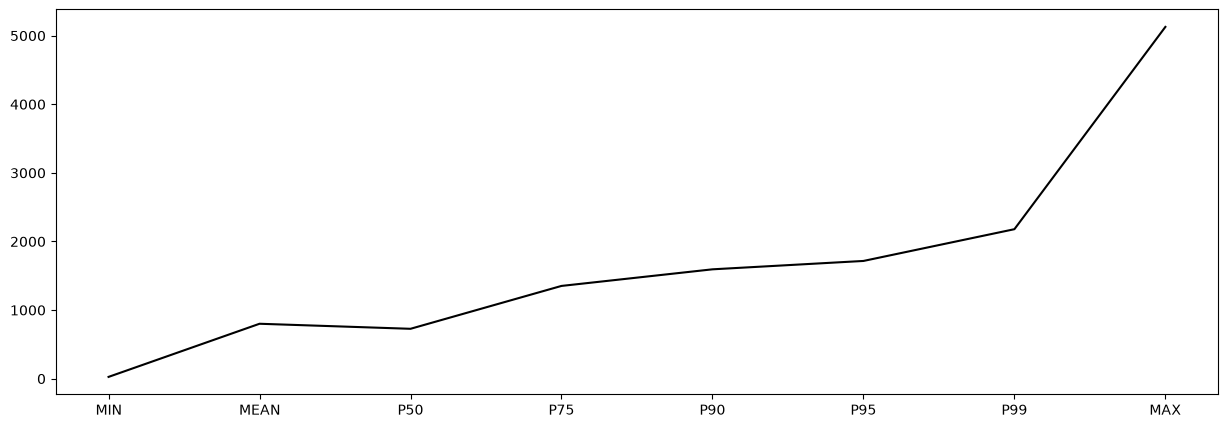

In [69]:
x = ["MIN", "MEAN", "P50", "P75", "P90", "P95", "P99", "MAX"]
y = [MIN, MÉDIA, P50, P75, P90, P95, P99, MAX]

"""
y |
  |
  |
  |
  |_ _ _ _ _ _ _ x
"""

plt.figure (figsize = (15, 5))
plt.plot (x, y, color = "black")
plt.show ()

In [73]:
for x in dataset["input_ids"][:5]:
    #if len (x) == MÉDIA:
    exemplo_dataset_média = TOKENIZER.decode (x)

    print (exemplo_dataset_média)
    print ("---" *50)

<|im_start|>user
De que forma o provérbio “A tenda quer-se com quem a entenda” reflete a sabedoria popular portuguesa?<|im_end|>
<|im_start|>assistant
<think>

</think>

Este provérbio demonstra a importância da compatibilidade e do entendimento mútuo nas relações interpessoais. Sugere que as pessoas procuram a companhia de quem as compreende e partilha os seus valores. Por exemplo, um artesão procurará vender os seus produtos a alguém que aprecie o seu trabalho e entenda o valor da sua arte, em vez de tentar convencer quem não o compreende.<|im_end|>

------------------------------------------------------------------------------------------------------------------------------------------------------
<|im_start|>user
O que nos ensina o provérbio “Quem nasce redondo, não morre quadrado” sobre a natureza humana e a capacidade de adaptação?<|im_end|>
<|im_start|>assistant
<think>

</think>

Este provérbio ensina que a essência de uma pessoa permanece ao longo da vida. Alguém com uma predi